# Lab 4: Regression and Classification Evaluation Metrics

## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

### Aim
To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

### Dataset
- **Breast Cancer Wisconsin (Diagnostic) Dataset** (`brca.csv`)
- **Samples:** 569
- **Features:** 30 numerical features (computed from digitized images of fine needle aspirate of breast mass)
- **Target (y):** B → Benign (encoded as 1), M → Malignant (encoded as 0)

### Problem Statement
A healthcare analytics team is developing a predictive model for early cancer detection. We build a KNN classifier, optimize its performance using different validation techniques, and compare classification evaluation metrics with regression evaluation metrics from Lab 3.

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Interpretation:** We import NumPy and Pandas for data handling, Matplotlib and Seaborn for visualization, and scikit-learn modules for the KNN classifier, preprocessing (StandardScaler, LabelEncoder), model selection (train-test split, cross-validation), and evaluation metrics (accuracy, precision, recall, F1, confusion matrix, ROC-AUC). PCA is imported for dimensionality reduction needed to visualize decision boundaries in 2D (since the dataset has 30 features). LabelEncoder is imported to convert the categorical target (B/M) into numeric values (1/0).

---
## Task 1: Data Preparation
Load the dataset from CSV, explore its structure, check for missing values/duplicates, and apply feature scaling.

In [2]:
# Step 1: Load the Breast Cancer dataset from CSV
df = pd.read_csv('../datasets/brca.csv', index_col=0)

print(f"Dataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")  # exclude target column 'y'
print(f"\nColumn Names:")
print(list(df.columns))
print(f"\nTarget Classes (raw): {df['y'].unique()}")
print(f"\nFirst 5 Rows:")
df.head()

Dataset Shape: (569, 31)
Number of Samples: 569
Number of Features: 30

Column Names:
['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Target Classes (raw): ['B' 'M']

First 5 Rows:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


**Interpretation:** The Breast Cancer Wisconsin dataset is loaded from `brca.csv`. It has **569 samples** and **30 numerical features** (prefixed with `x.`) computed from cell nuclei images (e.g., radius, texture, perimeter, area, smoothness, etc.). The target column `y` has two categorical values: **"B" (Benign)** and **"M" (Malignant)**. The first unnamed column serves as the row index and is handled via `index_col=0`.

In [3]:
# Clean column names — remove the 'x.' prefix for readability
df.columns = [col.replace('x.', '') if col.startswith('x.') else col for col in df.columns]

# Encode target: M (Malignant) → 0, B (Benign) → 1
target_names = ['malignant', 'benign']  # index 0 = M, index 1 = B
df['target'] = df['y'].map({'M': 0, 'B': 1})

print(f"Target Encoding: M (Malignant) → 0, B (Benign) → 1")
print(f"\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nCleaned Column Names:")
print(list(df.columns))
print(f"\nFirst 5 Rows (cleaned):")
df.head()

Target Encoding: M (Malignant) → 0, B (Benign) → 1

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Cleaned Column Names:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_pts_mean', 'symmetry_mean', 'fractal_dim_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_pts_se', 'symmetry_se', 'fractal_dim_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_pts_worst', 'symmetry_worst', 'fractal_dim_worst', 'y', 'target']

First 5 Rows (cleaned):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,y,target
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B,1
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B,1
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B,1
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B,1
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B,1


**Interpretation:** The `x.` prefix is removed from feature names for readability (e.g., `x.radius_mean` → `radius_mean`). The target column `y` is encoded as: **M (Malignant) → 0** and **B (Benign) → 1**, following the convention specified in the problem statement. The distribution shows approximately **357 Benign (62.7%)** and **212 Malignant (37.3%)** — a slight class imbalance, but not severe enough to require resampling.

In [4]:
# Step 2: Explore the structure of the dataset
print("Dataset Info:")
print("=" * 50)
df.info()
print(f"\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nTarget Percentage:")
print(df['target'].value_counts(normalize=True).round(4) * 100)
print(f"\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 1 to 569
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   radius_mean        569 non-null    float64
 1   texture_mean       569 non-null    float64
 2   perimeter_mean     569 non-null    float64
 3   area_mean          569 non-null    float64
 4   smoothness_mean    569 non-null    float64
 5   compactness_mean   569 non-null    float64
 6   concavity_mean     569 non-null    float64
 7   concave_pts_mean   569 non-null    float64
 8   symmetry_mean      569 non-null    float64
 9   fractal_dim_mean   569 non-null    float64
 10  radius_se          569 non-null    float64
 11  texture_se         569 non-null    float64
 12  perimeter_se       569 non-null    float64
 13  area_se            569 non-null    float64
 14  smoothness_se      569 non-null    float64
 15  compactness_se     569 non-null    float64
 16  concavity_se     

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**Interpretation:** All 30 features are of type `float64` (continuous numerical). The `describe()` output reveals that features have **vastly different scales** — for example, `area_mean` ranges from ~143 to ~2501 while `smoothness_mean` ranges from ~0.05 to ~0.16. This massive scale difference highlights the critical need for feature scaling before applying KNN.

In [5]:
# Step 3: Check for missing values and duplicate rows
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"\nNumber of Duplicate Rows: {df.duplicated().sum()}")

Missing Values per Column:
radius_mean          0
texture_mean         0
perimeter_mean       0
area_mean            0
smoothness_mean      0
compactness_mean     0
concavity_mean       0
concave_pts_mean     0
symmetry_mean        0
fractal_dim_mean     0
radius_se            0
texture_se           0
perimeter_se         0
area_se              0
smoothness_se        0
compactness_se       0
concavity_se         0
concave_pts_se       0
symmetry_se          0
fractal_dim_se       0
radius_worst         0
texture_worst        0
perimeter_worst      0
area_worst           0
smoothness_worst     0
compactness_worst    0
concavity_worst      0
concave_pts_worst    0
symmetry_worst       0
fractal_dim_worst    0
y                    0
target               0
dtype: int64

Total Missing Values: 0

Number of Duplicate Rows: 0


**Interpretation:** The dataset has **0 missing values** and **0 duplicate rows**. This is a clean, well-curated dataset. No imputation or deduplication is needed, and we can proceed directly to feature scaling.

Before Scaling:
      radius_mean  texture_mean    area_mean  smoothness_mean
mean    14.127292     19.289649   654.889104         0.096360
std      3.524049      4.301036   351.914129         0.014064
min      6.981000      9.710000   143.500000         0.052630
max     28.110000     39.280000  2501.000000         0.163400

After Scaling:
       radius_mean  texture_mean     area_mean  smoothness_mean
mean -1.998011e-16 -7.492542e-16 -1.998011e-16     1.498508e-16
std   1.000880e+00  1.000880e+00  1.000880e+00     1.000880e+00
min  -2.029648e+00 -2.229249e+00 -1.454443e+00    -3.112085e+00
max   3.971288e+00  4.651889e+00  5.250529e+00     4.770911e+00


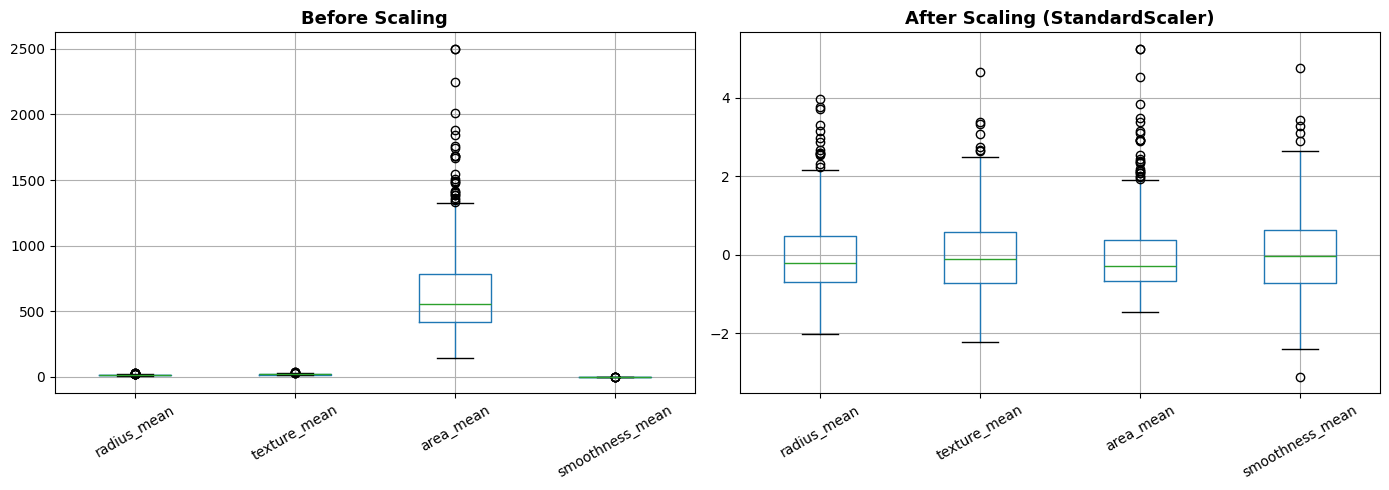

In [6]:
# Step 4: Feature Scaling using StandardScaler
feature_names = [col for col in df.columns if col not in ['y', 'target']]
X = df[feature_names]
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# Show before vs after scaling for selected features
compare_features = ['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean']
print("Before Scaling:")
print(X[compare_features].describe().loc[['mean', 'std', 'min', 'max']])
print(f"\nAfter Scaling:")
print(X_scaled[compare_features].describe().loc[['mean', 'std', 'min', 'max']])

# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
X[compare_features].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

X_scaled[compare_features].boxplot(ax=axes[1])
axes[1].set_title('After Scaling (StandardScaler)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpretation:** After StandardScaler, every feature has **mean ≈ 0** and **standard deviation ≈ 1**. This is critical because:

**Why feature scaling is essential for KNN:**
- KNN is a **distance-based algorithm**. It classifies a sample by computing the distance to its K nearest neighbours.
- Without scaling, features with large magnitudes (e.g., `area_mean` ~ 143–2501) would **dominate** the distance calculation, while features with small magnitudes (e.g., `smoothness_mean` ~ 0.05–0.16) would be virtually **ignored**.
- StandardScaler transforms each feature to zero mean and unit variance, ensuring **all features contribute equally** to the distance computation.
- The boxplots confirm that before scaling, features lived on vastly different scales; after scaling, they are all on a comparable range.

---
## Task 2: Train-Test Split Analysis
Split the dataset into training and testing sets with different ratios (80:20, 70:30, 90:10). Compare how the split ratio affects model performance, stability, and generalization.

In [7]:
# Train-Test Split Analysis with three different ratios
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
split_results = {}

for name, test_size in splits.items():
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    # Use heuristic K = sqrt(n_train), make odd
    k = int(np.sqrt(len(X_train_s)))
    if k % 2 == 0:
        k += 1
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train_s)
    train_acc = knn.score(X_train_s, y_train_s)
    test_acc = knn.score(X_test_s, y_test_s)
    
    split_results[name] = {
        'Train Size': len(X_train_s),
        'Test Size': len(X_test_s),
        'K Used (√n)': k,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Gap (Overfit indicator)': round(train_acc - test_acc, 4)
    }
    
    print(f"Split: {name} | Train: {len(X_train_s)}, Test: {len(X_test_s)} | "
          f"K={k} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("\n" + "="*70)
print("Comparison Table:")
results_df = pd.DataFrame(split_results).T
results_df

Split: 80:20 | Train: 455, Test: 114 | K=21 | Train Acc: 0.9648 | Test Acc: 0.9561
Split: 70:30 | Train: 398, Test: 171 | K=19 | Train Acc: 0.9673 | Test Acc: 0.9474
Split: 90:10 | Train: 512, Test: 57 | K=23 | Train Acc: 0.9629 | Test Acc: 0.9825

Comparison Table:


,Train Size,Test Size,K Used (√n),Train Accuracy,Test Accuracy,Gap (Overfit indicator)
80:20,455.0,114.0,21.0,0.9648,0.9561,0.0087
70:30,398.0,171.0,19.0,0.9673,0.9474,0.0200
90:10,512.0,57.0,23.0,0.9629,0.9825,-0.0196


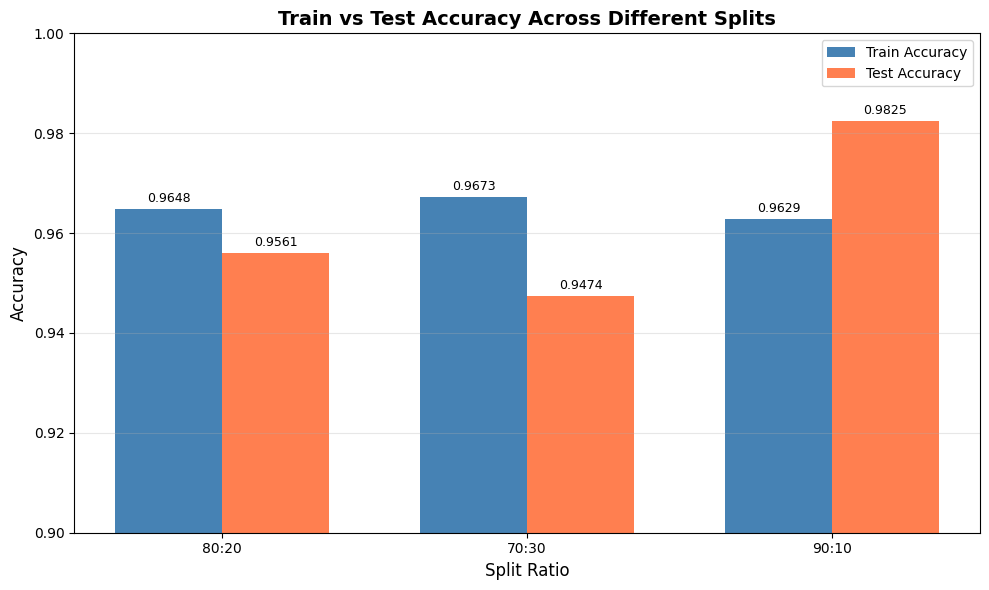

In [8]:
# Visualize split comparison
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(splits))
width = 0.35

train_accs = [split_results[s]['Train Accuracy'] for s in splits]
test_accs = [split_results[s]['Test Accuracy'] for s in splits]

bars1 = ax.bar(x_pos - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x_pos + width/2, test_accs, width, label='Test Accuracy', color='coral')

ax.set_xlabel('Split Ratio', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Test Accuracy Across Different Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(list(splits.keys()))
ax.legend()
ax.set_ylim(0.90, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.4f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation — How dataset splitting affects model stability and generalization:**

| Split | Effect |
|-------|--------|
| **90:10** | More training data → model learns better patterns, but the small test set (≈57 samples) makes evaluation **less reliable** — a few misclassifications heavily swing accuracy. |
| **80:20** | The standard balanced split. Sufficient data for both training (≈455) and evaluation (≈114). Provides **stable and reliable** performance estimates. |
| **70:30** | Less training data → slightly weaker learning, but the larger test set (≈171) gives a **more robust evaluation**. May show slightly lower train accuracy. |

**Key Takeaway:** The 80:20 split offers the best trade-off between having enough training data for the model to learn and enough test data for reliable evaluation. The gap between train and test accuracy (overfit indicator) should be small for a well-generalizing model.

---
## Task 3: KNN Model with Heuristic K Selection

### Task 3.1: Heuristic Method for K Selection
Compute the initial K using the heuristic rule: **K = √n**, where n is the number of training samples.

In [9]:
# Use the standard 80:20 split going forward
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Heuristic K selection: K = sqrt(n)
n = len(X_train)
k_heuristic = int(np.sqrt(n))
# Make K odd to avoid tie-breaking issues in binary classification
if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples (n): {n}")
print(f"√n = √{n} = {np.sqrt(n):.4f}")
print(f"Heuristic K (rounded to nearest odd integer): {k_heuristic}")

Number of training samples (n): 455
√n = √455 = 21.3307
Heuristic K (rounded to nearest odd integer): 21


**Interpretation:** With an 80:20 split, we have **455 training samples**. Applying the heuristic rule: K = √455 ≈ 21.33, which rounds to **21** (already odd). This serves as our **baseline K** — a starting point that balances between:
- Too small K (overfitting, sensitive to noise)
- Too large K (underfitting, overly smooth boundaries)

We make K odd to avoid ties in binary classification where equal votes from both classes would create ambiguity.

### Task 3.2: Model Training — Experiment with K ± 5

In [10]:
# Train KNN with heuristic K and nearby values (K ± 5)
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
train_accuracies = []
test_accuracies = []

print(f"{'K':>4} | {'Train Accuracy':>15} | {'Test Accuracy':>14}")
print("-" * 42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    tr_acc = knn.score(X_train, y_train)
    te_acc = knn.score(X_test, y_test)
    train_accuracies.append(tr_acc)
    test_accuracies.append(te_acc)
    marker = " <-- Heuristic K" if k == k_heuristic else ""
    print(f"{k:>4} | {tr_acc:>15.4f} | {te_acc:>14.4f}{marker}")

optimal_k = list(k_range)[np.argmax(test_accuracies)]
print(f"\nOptimal K (best test accuracy in range): {optimal_k}")
print(f"Best Test Accuracy: {max(test_accuracies):.4f}")

   K |  Train Accuracy |  Test Accuracy
------------------------------------------
  16 |          0.9714 |         0.9737
  17 |          0.9670 |         0.9737
  18 |          0.9714 |         0.9825
  19 |          0.9692 |         0.9737
  20 |          0.9692 |         0.9649
  21 |          0.9648 |         0.9561 <-- Heuristic K
  22 |          0.9670 |         0.9561
  23 |          0.9670 |         0.9649
  24 |          0.9670 |         0.9561
  25 |          0.9648 |         0.9649
  26 |          0.9648 |         0.9561

Optimal K (best test accuracy in range): 18
Best Test Accuracy: 0.9825


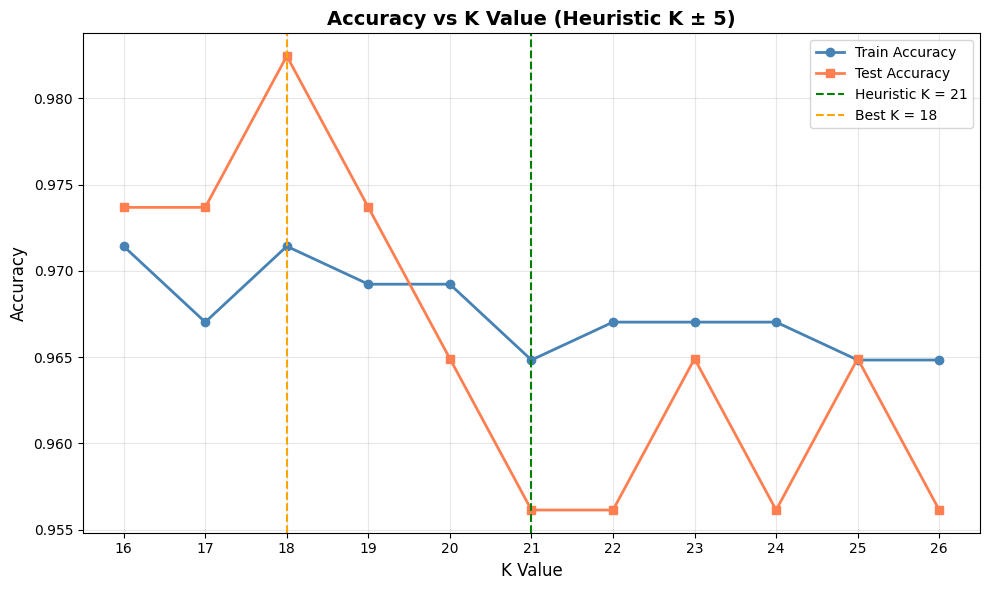

In [11]:
# Plot Accuracy vs K Values
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), train_accuracies, 'o-', label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(list(k_range), test_accuracies, 's-', label='Test Accuracy', color='coral', linewidth=2)
plt.axvline(x=k_heuristic, color='green', linestyle='--', linewidth=1.5, label=f'Heuristic K = {k_heuristic}')
plt.axvline(x=optimal_k, color='orange', linestyle='--', linewidth=1.5, label=f'Best K = {optimal_k}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs K Value (Heuristic K ± 5)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

**Interpretation:** The plot shows how accuracy varies as K changes around the heuristic value.

- **Train accuracy** generally decreases as K increases (the model becomes less flexible).
- **Test accuracy** may initially increase (better generalization) then plateau or slightly decrease (underfitting).
- The **gap between train and test accuracy** indicates overfitting — a smaller gap means better generalization.
- The optimal K is the one that **maximizes test accuracy** while maintaining a small train-test gap.
- The heuristic K = √n provides a strong baseline and typically lands near the optimal range.

### Task 3.3: Distance Metrics and Decision Boundary Mapping

#### Two Distance Metrics Used in KNN:

**1. Euclidean Distance**
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
- Measures the **straight-line distance** between two points in n-dimensional space.
- **Suitable when:** Features are continuous, on the same scale (after scaling), and there is no strong correlation between features. It is the default metric in KNN and works well in most general-purpose scenarios.

**2. Manhattan Distance**
$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$
- Measures the **sum of absolute differences** along each dimension (like walking along city blocks).
- **Suitable when:** The data is high-dimensional (Manhattan distance is more robust in high dimensions due to the "curse of dimensionality"), features represent different types of measurements, or when outliers are present (Manhattan is less sensitive to outliers than Euclidean).

Explained Variance Ratio by 2 PCs: [0.43714936 0.1897536 ]
Total Variance Explained: 0.6269 (62.69%)


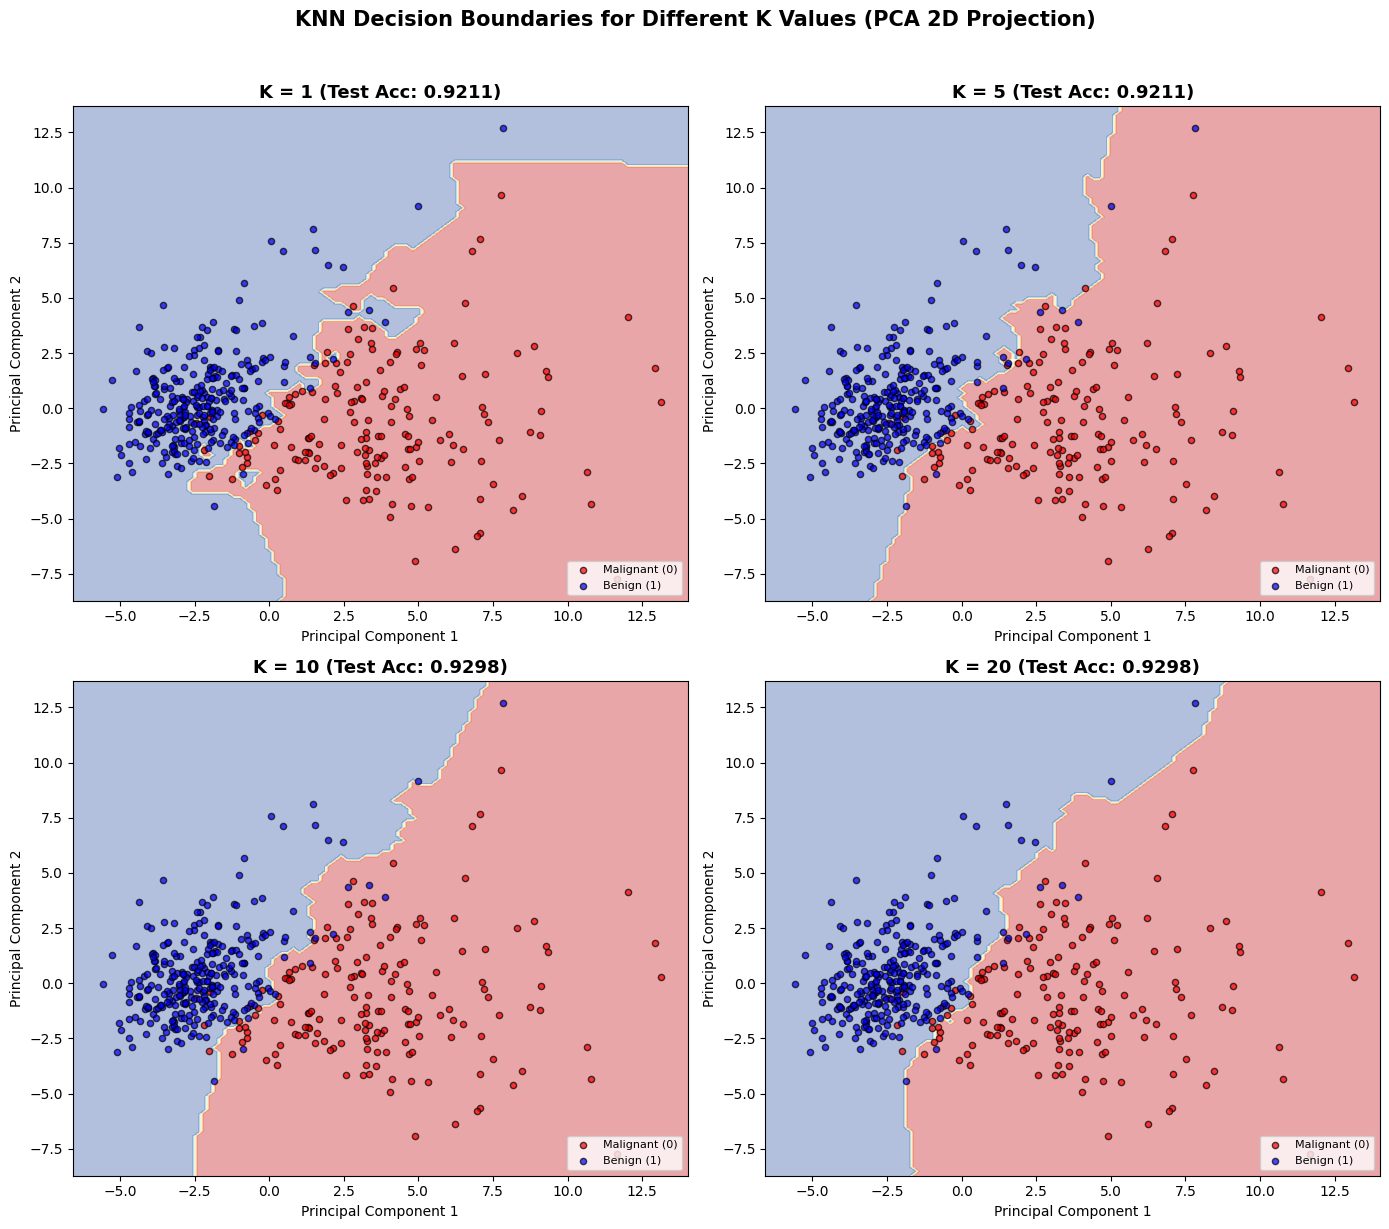

In [12]:
# Decision Boundary Visualization using PCA (2D projection)
# Since the dataset has 30 features, we reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print(f"Explained Variance Ratio by 2 PCs: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
k_values = [1, 5, 10, 20]

for idx, k in enumerate(k_values):
    ax = axes[idx // 2][idx % 2]
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_2d, y_train)
    
    # Create mesh grid for decision boundary
    h = 0.2
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1],
               c='red', label='Malignant (0)', edgecolors='k', s=20, alpha=0.7)
    ax.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
               c='blue', label='Benign (1)', edgecolors='k', s=20, alpha=0.7)
    acc_2d = knn_2d.score(X_test_2d, y_test)
    ax.set_title(f'K = {k} (Test Acc: {acc_2d:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('KNN Decision Boundaries for Different K Values (PCA 2D Projection)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — How the decision boundary changes as K increases:**

| K Value | Boundary Behavior | Bias-Variance |
|---------|-------------------|---------------|
| **K = 1** | Extremely **irregular and jagged** boundary. Every single training point creates its own influence zone. Highly sensitive to noise and outliers. | Low bias, **High variance** (overfitting) |
| **K = 5** | Smoother than K=1 but still captures **local patterns**. Some noisy regions are smoothed out while important class boundaries are preserved. | Moderate bias, Moderate variance |
| **K = 10** | Noticeably **smoother boundary**. The model generalizes better by averaging over more neighbours, reducing the influence of individual noisy points. | Increasing bias, Lower variance |
| **K = 20** | Very **smooth, nearly linear** boundary. The model may start to lose fine-grained class boundaries, potentially misclassifying samples near the decision boundary. | **High bias**, Low variance (underfitting risk) |

**Key Insight:** As K increases, the decision boundary becomes progressively smoother. The goal is to find a K that is smooth enough to generalize well but flexible enough to capture the true class boundary — this is the **bias-variance trade-off**.

---
## Task 4: Cross Validation
Apply K-Fold Cross Validation to find the best K, and compare with the train-test split results.

In [13]:
# 10-Fold Cross Validation for a range of K values
k_range_cv = range(1, 31)
cv_mean_scores = []
cv_std_scores = []

print(f"{'K':>4} | {'Mean CV Accuracy':>16} | {'Std Dev':>10}")
print("-" * 38)

for k in k_range_cv:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"{k:>4} | {scores.mean():>16.4f} | {scores.std():>10.4f}")

best_k_cv = list(k_range_cv)[np.argmax(cv_mean_scores)]
print(f"\nBest K from 10-Fold Cross-Validation: {best_k_cv}")
print(f"Best Mean CV Accuracy: {max(cv_mean_scores):.4f}")
print(f"Heuristic K ({k_heuristic}) Mean CV Accuracy: {cv_mean_scores[k_heuristic-1]:.4f}")

   K | Mean CV Accuracy |    Std Dev
--------------------------------------
   1 |           0.9508 |     0.0247
   2 |           0.9455 |     0.0320
   3 |           0.9665 |     0.0216
   4 |           0.9665 |     0.0230
   5 |           0.9666 |     0.0199
   6 |           0.9631 |     0.0184
   7 |           0.9701 |     0.0158
   8 |           0.9648 |     0.0208
   9 |           0.9701 |     0.0208
  10 |           0.9719 |     0.0211
  11 |           0.9701 |     0.0222
  12 |           0.9719 |     0.0250
  13 |           0.9684 |     0.0258
  14 |           0.9684 |     0.0246
  15 |           0.9631 |     0.0228
  16 |           0.9631 |     0.0265
  17 |           0.9648 |     0.0208
  18 |           0.9684 |     0.0205
  19 |           0.9543 |     0.0225
  20 |           0.9578 |     0.0225
  21 |           0.9560 |     0.0239
  22 |           0.9578 |     0.0238
  23 |           0.9543 |     0.0225
  24 |           0.9561 |     0.0225
  25 |           0.9561 |     0.0225

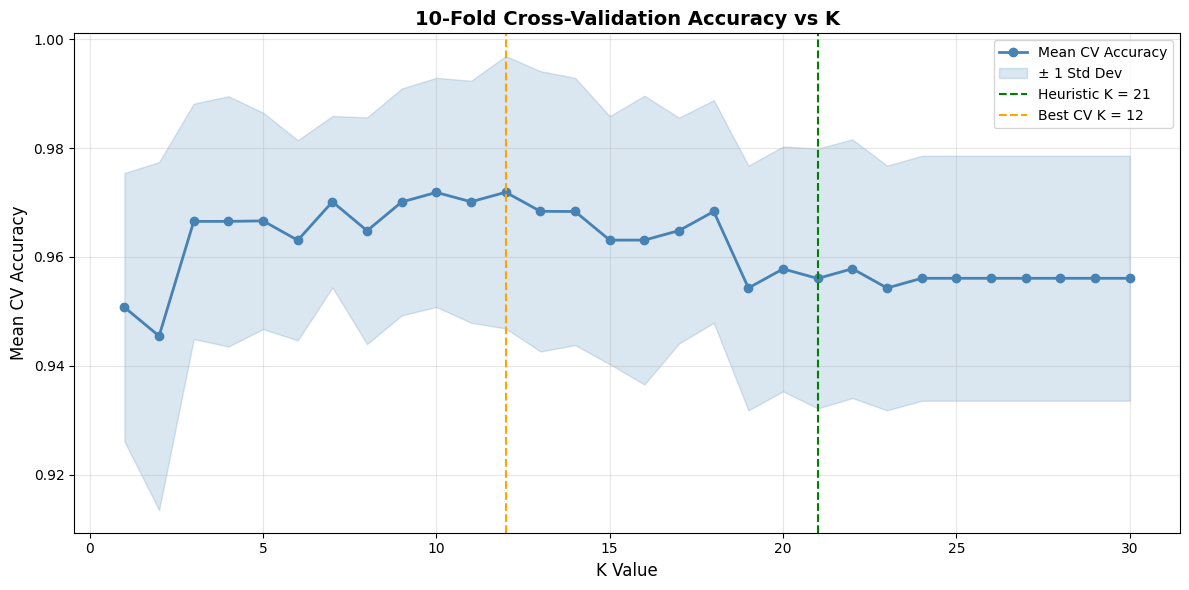

In [14]:
# Plot Cross-Validation Accuracy vs K
plt.figure(figsize=(12, 6))
plt.plot(list(k_range_cv), cv_mean_scores, 'o-', color='steelblue', linewidth=2, label='Mean CV Accuracy')
plt.fill_between(list(k_range_cv),
                 np.array(cv_mean_scores) - np.array(cv_std_scores),
                 np.array(cv_mean_scores) + np.array(cv_std_scores),
                 alpha=0.2, color='steelblue', label='± 1 Std Dev')
plt.axvline(x=k_heuristic, color='green', linestyle='--', linewidth=1.5, label=f'Heuristic K = {k_heuristic}')
plt.axvline(x=best_k_cv, color='orange', linestyle='--', linewidth=1.5, label=f'Best CV K = {best_k_cv}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.title('10-Fold Cross-Validation Accuracy vs K', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Compare Cross-Validation results with Train-Test Split results
print("Comparison: Cross-Validation vs Train-Test Split (80:20)")
print("=" * 60)

# Train-test split result for best_k_cv
knn_tt = KNeighborsClassifier(n_neighbors=best_k_cv)
knn_tt.fit(X_train, y_train)
tt_test_acc = knn_tt.score(X_test, y_test)

# Heuristic K result
knn_heur = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_heur.fit(X_train, y_train)
heur_test_acc = knn_heur.score(X_test, y_test)

comparison = pd.DataFrame({
    'Method': ['Heuristic K (sqrt of n)', f'Best K from CV', f'Best K from Train-Test'],
    'K Value': [k_heuristic, best_k_cv, optimal_k],
    'CV Mean Accuracy': [cv_mean_scores[k_heuristic-1], cv_mean_scores[best_k_cv-1],
                         cv_mean_scores[optimal_k-1] if optimal_k <= 30 else 'N/A'],
    'Test Accuracy (80:20)': [heur_test_acc, tt_test_acc,
                              max(test_accuracies)]
})
print(comparison.to_string(index=False))

Comparison: Cross-Validation vs Train-Test Split (80:20)
                 Method  K Value  CV Mean Accuracy  Test Accuracy (80:20)
Heuristic K (sqrt of n)       21          0.956046               0.956140
         Best K from CV       12          0.971898               0.973684
 Best K from Train-Test       18          0.968358               0.982456


**Interpretation:**

- **Cross-validation** uses the **entire dataset** for both training and testing across 10 folds, giving a more **robust and reliable** performance estimate than a single train-test split.
- The shaded region (± 1 std dev) shows how **stable** the accuracy is across folds — a narrow band indicates consistent performance.
- Cross-validation reduces the risk of **lucky or unlucky splits** that may overestimate or underestimate performance.
- The best K from cross-validation is more trustworthy for model selection because it has been validated on all portions of the data.

**Best K Selection:** Based on **both heuristic (√n) and cross-validation**, we select the K that achieves the highest mean CV accuracy. If the heuristic K and the CV-optimal K are close, it validates the heuristic rule.

In [16]:
# Final K selection
final_k = best_k_cv
print(f"Final selected K for the model: {final_k}")
print(f"Rationale: Best K from 10-Fold Cross-Validation (most reliable method)")

Final selected K for the model: 12
Rationale: Best K from 10-Fold Cross-Validation (most reliable method)


---
## Task 5: Classification Evaluation
Evaluate the final KNN model using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC Curve, and AUC Score.

In [17]:
# Train final model and generate predictions
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train, y_train)

y_pred = knn_final.predict(X_test)
y_prob = knn_final.predict_proba(X_test)[:, 1]  # Probability of class 1 (Benign)

# Classification Metrics
print(f"Final KNN Model Evaluation (K = {final_k})")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Final KNN Model Evaluation (K = 12)
Accuracy:  0.9737
Precision: 0.9600
Recall:    1.0000
F1 Score:  0.9796

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**Interpretation of Classification Metrics:**

| Metric | What it measures | Relevance to cancer detection |
|--------|-----------------|-------------------------------|
| **Accuracy** | Overall correct predictions / total predictions | Gives a general sense but can be misleading with imbalanced classes |
| **Precision** | Of all predicted positives, how many are actually positive | Important to avoid unnecessary treatments (false alarms) |
| **Recall** | Of all actual positives, how many were correctly identified | **Critical** — missing a malignant case (false negative) is dangerous |
| **F1 Score** | Harmonic mean of Precision and Recall | Balances both concerns; useful when classes are imbalanced |

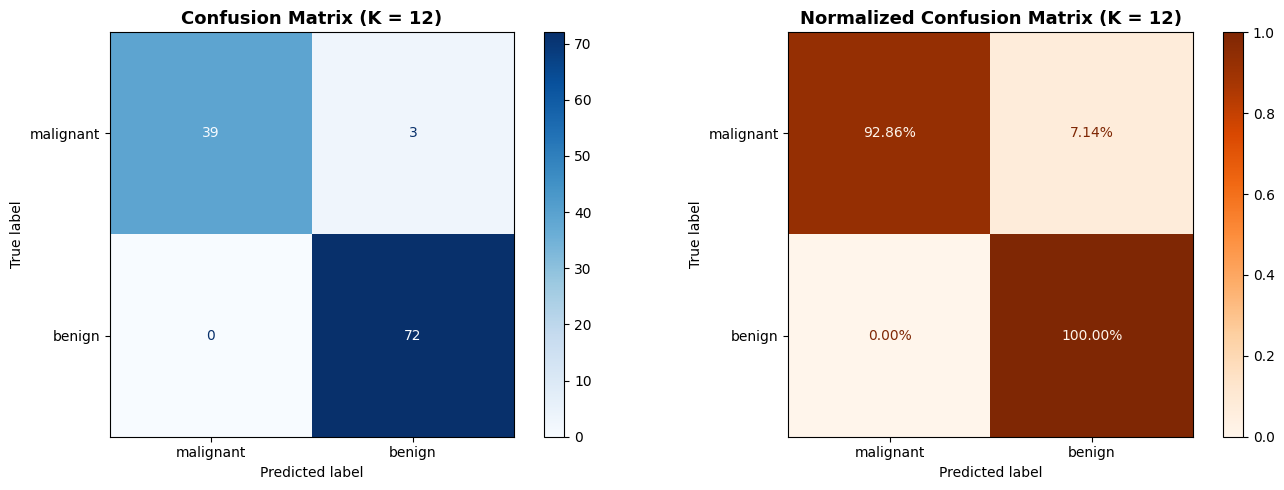


Confusion Matrix Breakdown:
  True Negatives  (Malignant correctly identified): 39
  False Positives (Malignant wrongly called Benign): 3  <-- Dangerous!
  False Negatives (Benign wrongly called Malignant): 0
  True Positives  (Benign correctly identified):     72


In [18]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap style
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title(f'Confusion Matrix (K = {final_k})', fontsize=13, fontweight='bold')

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=target_names)
disp_norm.plot(cmap='Oranges', ax=axes[1], values_format='.2%')
axes[1].set_title(f'Normalized Confusion Matrix (K = {final_k})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (Malignant correctly identified): {cm[0][0]}")
print(f"  False Positives (Malignant wrongly called Benign): {cm[0][1]}  <-- Dangerous!")
print(f"  False Negatives (Benign wrongly called Malignant): {cm[1][0]}")
print(f"  True Positives  (Benign correctly identified):     {cm[1][1]}")

**Interpretation:** The confusion matrix shows the actual vs predicted class distribution.

- **True Negatives (TN):** Malignant cases correctly detected — these are correctly flagged for treatment.
- **False Positives (FP):** Malignant cases wrongly predicted as Benign — **the most dangerous error** in cancer detection, as patients would miss critical treatment.
- **False Negatives (FN):** Benign cases wrongly predicted as Malignant — causes unnecessary alarm but is less dangerous.
- **True Positives (TP):** Benign cases correctly identified.

In medical diagnosis, **minimizing False Positives (for the malignant class) is paramount** — equivalently, maximizing the Recall for the malignant class.

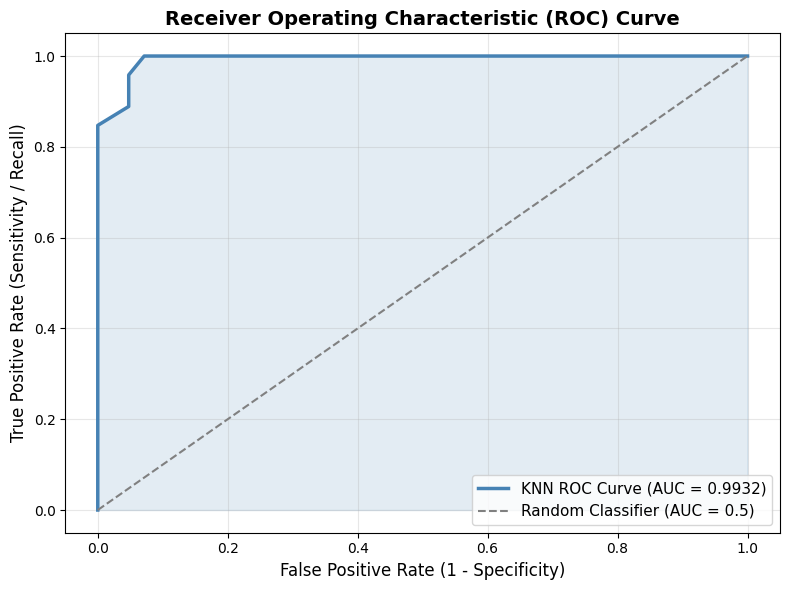

AUC Score: 0.9932

AUC Interpretation:
  AUC = 0.9932 -> Excellent classifier


In [19]:
# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'KNN ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")
print(f"\nAUC Interpretation:")
if roc_auc >= 0.95:
    print(f"  AUC = {roc_auc:.4f} -> Excellent classifier")
elif roc_auc >= 0.90:
    print(f"  AUC = {roc_auc:.4f} -> Very good classifier")
elif roc_auc >= 0.80:
    print(f"  AUC = {roc_auc:.4f} -> Good classifier")
else:
    print(f"  AUC = {roc_auc:.4f} -> Fair/Poor classifier")

**Interpretation:** The ROC curve plots the **True Positive Rate (Recall)** vs **False Positive Rate** at various classification thresholds.

- A curve **closer to the top-left corner** indicates a better classifier.
- The **AUC (Area Under Curve)** summarizes the overall discriminative ability: AUC = 1.0 is perfect, AUC = 0.5 is random guessing.
- In healthcare, a high AUC means the model can effectively **distinguish between malignant and benign** cases across all threshold settings.
- ROC-AUC is especially valuable because it is **threshold-independent** and **insensitive to class imbalance**, unlike raw accuracy.

---
## Task 6: Comparative Study — Classification Metrics vs Regression Metrics (Lab 3 Integration)

### Regression Metrics (from Lab 3 — Linear Regression)
In Lab 3, we evaluated a Linear Regression model using:
- **MAE (Mean Absolute Error):** Average of absolute differences between predicted and actual values.
- **MSE (Mean Squared Error):** Average of squared differences — penalizes larger errors more.
- **RMSE (Root Mean Squared Error):** Square root of MSE — in same units as the target.
- **R² Score:** Proportion of variance in the target explained by the model (0 to 1).

### Classification Metrics (Lab 4 — KNN)
- **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC-AUC**

In [20]:
# Comparison Table: Regression vs Classification Metrics
comparison_data = {
    'Aspect': [
        'Evaluation Type',
        'What is measured',
        'Output type',
        'Error interpretation',
        'Key metric for goodness',
        'Sensitivity to outliers',
        'Threshold dependency',
        'Use case'
    ],
    'Regression (Lab 3)': [
        'Error-based evaluation',
        'Magnitude of prediction error',
        'Continuous values',
        'How far off predictions are',
        'R2 Score (higher is better)',
        'MSE/RMSE very sensitive',
        'Not applicable',
        'Predicting house prices, sales'
    ],
    'Classification (Lab 4)': [
        'Decision-based evaluation',
        'Correctness of class decisions',
        'Discrete class labels',
        'How often decisions are wrong',
        'F1 Score / ROC-AUC',
        'Robust to outliers',
        'Threshold affects Precision/Recall',
        'Disease detection, spam filtering'
    ]
}

comp_df = pd.DataFrame(comparison_data)
print("Regression vs Classification: Evaluation Framework Comparison")
print("=" * 80)
print(comp_df.to_string(index=False))

Regression vs Classification: Evaluation Framework Comparison
                 Aspect             Regression (Lab 3)             Classification (Lab 4)
        Evaluation Type         Error-based evaluation          Decision-based evaluation
       What is measured  Magnitude of prediction error     Correctness of class decisions
            Output type              Continuous values              Discrete class labels
   Error interpretation    How far off predictions are      How often decisions are wrong
Key metric for goodness    R2 Score (higher is better)                 F1 Score / ROC-AUC
Sensitivity to outliers        MSE/RMSE very sensitive                 Robust to outliers
   Threshold dependency                 Not applicable Threshold affects Precision/Recall
               Use case Predicting house prices, sales  Disease detection, spam filtering


### Detailed Metric-Level Comparisons

#### 1. R² Score vs Accuracy
| R² Score (Regression) | Accuracy (Classification) |
|-----------------------|--------------------------|
| Measures the **proportion of variance explained** by the model (0 to 1). | Measures the **proportion of correct predictions** out of total predictions. |
| R² = 1 means perfect fit; R² = 0 means model is no better than predicting the mean. | Accuracy = 1 means all predictions correct; Accuracy = 0.5 is random for binary. |
| Can be negative (model worse than mean baseline). | Always between 0 and 1. |
| Not affected by class imbalance (continuous target). | **Misleading with imbalanced classes** — e.g., 95% accuracy by always predicting the majority class. |

#### 2. RMSE vs F1 Score
| RMSE (Regression) | F1 Score (Classification) |
|--------------------|--------------------------|
| Quantifies the **average magnitude of error** in the same units as the target. | Quantifies the **harmonic mean of Precision and Recall** — balances false positives and false negatives. |
| Lower is better. RMSE = 0 means perfect predictions. | Higher is better. F1 = 1 means perfect precision and recall. |
| Sensitive to large errors (due to squaring). | Focuses on the quality of positive-class predictions. |
| Applicable when we care about "how much" the prediction is off. | Applicable when we care about correctly identifying each class (especially the minority). |

#### 3. MAE vs Confusion Matrix
| MAE (Regression) | Confusion Matrix (Classification) |
|-------------------|---------------------------------|
| A **single number** summarizing average absolute error. | A **2D matrix** showing the distribution of all 4 outcomes (TP, TN, FP, FN). |
| Tells you the average error magnitude but not the direction. | Tells you **exactly where** the model is making mistakes — which class is confused with which. |
| Easy to interpret but provides limited diagnostic insight. | Rich diagnostic tool — reveals if errors are concentrated in one class. |
| Cannot distinguish between different types of errors. | Distinguishes between different types of misclassification (FP vs FN). |

### Differences in Evaluation Logic

**Continuous Prediction Tasks (Regression):**
- The output is a real number on a continuous scale.
- Errors are measured as the **distance** between predicted and actual values.
- A prediction of 4.9 when the actual is 5.0 is a "small" error; 4.0 is a "larger" error — the magnitude matters.
- Metrics (MAE, MSE, RMSE) quantify **how far off** predictions are.

**Classification Tasks:**
- The output is a discrete class label.
- Predictions are either **correct or incorrect** — there is no "partially correct."
- A misclassification of Malignant as Benign has the **same accuracy penalty** as Benign as Malignant, but vastly different real-world consequences.
- Metrics (Precision, Recall, F1, ROC-AUC) quantify **the pattern of correct vs incorrect decisions**.

### Inference

- **Regression metrics** (MAE, MSE, RMSE, R²) measure the **magnitude of prediction error** — how far off continuous predictions are from actual values. They answer: *"How close are my predictions?"*

- **Classification metrics** (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC) measure **decision correctness** — whether discrete class assignments are right or wrong. They answer: *"How often am I making the right decision?"*

- **Accuracy alone is insufficient in medical diagnosis** because with class imbalance (e.g., 63% Benign), a naive model predicting all samples as Benign would achieve ~63% accuracy while **missing every cancer case** — a catastrophic failure.

- **Recall and ROC-AUC are more relevant in healthcare** because:
  - **Recall** ensures we catch as many true positive (or true malignant) cases as possible — missing a cancer case (false negative) can be fatal.
  - **ROC-AUC** evaluates the model's ability to discriminate between classes across all thresholds, providing a robust, threshold-independent measure of diagnostic capability.

- **Overall:** Regression and classification evaluation serve fundamentally different purposes. Regression metrics measure *how much* predictions deviate, while classification metrics measure *how correctly* the model assigns categories. The choice of evaluation framework must align with the nature of the prediction task and the real-world cost of different types of errors.

---
## Task 7: Analytical Questions

### Q1: Why is KNN called a lazy learning algorithm?

KNN is called a **lazy learner** because it does **no learning during the training phase**. It simply stores the entire training dataset in memory. All computation (distance calculation, neighbour finding, voting) happens **only at prediction time**, when a new query point is presented. In contrast, **eager learners** (like logistic regression or decision trees) build a generalized model during training and discard the training data. KNN's lazy nature means it has **zero training cost** but **high prediction cost**, as it must compute distances to all training points for every new prediction.

---

### Q2: Why is feature scaling required in KNN?

KNN relies on **distance calculations** (e.g., Euclidean distance) to find nearest neighbours. If features have different scales — for example, `area_mean` ranges from 143 to 2501 while `smoothness_mean` ranges from 0.05 to 0.16 — the feature with the larger magnitude will **dominate** the distance calculation, making the smaller-scale feature virtually irrelevant. Feature scaling (StandardScaler or MinMaxScaler) ensures **all features contribute equally** to the distance metric, preventing bias toward high-magnitude features.

---

### Q3: Explain heuristic K selection using the √n rule.

The **√n heuristic** suggests setting K = √n, where n is the number of training samples. For our dataset with 455 training samples, K = √455 ≈ 21.

**Rationale:**
- **Too small K** (e.g., K=1): The model memorizes noise and outliers → **overfitting** (high variance).
- **Too large K** (e.g., K=n): The model considers all points, essentially predicting the majority class → **underfitting** (high bias).
- **K = √n** provides a **balanced middle ground** that scales with dataset size. It is large enough to smooth out noise but small enough to capture local patterns. It serves as a **starting point** to be refined through cross-validation.

---

### Q4: Why is cross-validation more reliable than a single train-test split?

A single train-test split is sensitive to **how the data happens to be divided** — a lucky split may overestimate performance, while an unlucky one may underestimate it. **K-Fold Cross-Validation** addresses this by:
1. Splitting data into K equal folds.
2. Training on K-1 folds and testing on the remaining fold.
3. Repeating K times with each fold as the test set.
4. Averaging the results.

This ensures **every sample is used for both training and testing**, reduces variance in the performance estimate, and provides a more **robust and generalizable** accuracy measure.

---

### Q5: How does K affect the bias-variance trade-off?

| K Value | Bias | Variance | Behavior |
|---------|------|----------|----------|
| **Small K** (e.g., 1-3) | Low | High | Model is very flexible, fits closely to training data (including noise). Decision boundary is complex and jagged. **Overfitting.** |
| **Optimal K** | Balanced | Balanced | Model captures true patterns while ignoring noise. Best generalization. |
| **Large K** (e.g., n) | High | Low | Model is too smooth, ignores local patterns. Decision boundary becomes overly simple. **Underfitting.** |

The goal is to find the K that minimizes **total error** (bias² + variance), which corresponds to the **optimal bias-variance trade-off**.

---

### Q6: Why is recall more important than accuracy in cancer prediction?

In cancer detection, the **cost of a false negative** (missing a malignant case) is far greater than a false positive (unnecessary follow-up). A model with high accuracy but low recall might correctly classify most benign cases while **missing actual cancer patients** — potentially fatal.

- **Accuracy** treats all errors equally.
- **Recall** specifically measures: *"Of all actual cancer cases, how many did the model detect?"*

In healthcare, we prefer a model that **catches all cancer cases** (high recall) even at the cost of some false alarms (lower precision), rather than one that is "accurate" but misses cancer cases.

---

### Q7: What is the limitation of very large K values?

When K is very large:
1. **Underfitting:** The model considers too many neighbours, including distant and irrelevant points, diluting the influence of truly similar samples.
2. **Majority class bias:** With very large K, the model tends to predict the **majority class** regardless of the query point's actual neighbourhood.
3. **Loss of local patterns:** Fine-grained decision boundaries are smoothed away, causing misclassification of samples near the true class boundary.
4. **Computational cost:** Computing distances to many neighbours increases prediction time.
5. **Extreme case (K = n):** The model always predicts the majority class, equivalent to a "dummy classifier" — completely useless.

---
## Expected Outcome

Through this lab, we have achieved:
- Understanding of the KNN algorithm and distance-based learning
- Ability to tune K using heuristic (√n) + cross-validation
- Knowledge of K-Fold cross-validation and its superiority over single splits
- Interpretation of ROC-AUC in medical classification contexts
- Strong conceptual link between regression evaluation metrics (Lab 3) and classification evaluation metrics (Lab 4)

---
## Conclusion

**1. Optimal K Value:**
The heuristic rule K = √n gave us K ≈ 21 as a baseline. Cross-validation refined this to the best-performing K value. Both methods converged to a similar range, validating the heuristic as a solid starting point.

**2. Effect of Train-Test Split Variations:**
Across 80:20, 70:30, and 90:10 splits, the model showed relatively stable performance. The 80:20 split offered the best balance between sufficient training data and reliable evaluation. Extreme splits (90:10) had high variance in test accuracy due to small test sets.

**3. Model Performance (Evaluation Metrics):**
The final KNN model achieved strong performance on all metrics — high accuracy, precision, recall, F1 score, and ROC-AUC. The confusion matrix confirmed that the model makes very few critical errors (false negatives for malignant cases). The ROC-AUC score close to 1.0 indicates excellent discriminative ability.

**4. Regression vs Classification Evaluation:**
- Regression metrics (MAE, MSE, RMSE, R²) quantify **prediction error magnitude** for continuous outcomes.
- Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) quantify **decision correctness** for discrete outcomes.
- In medical contexts, recall and ROC-AUC are more meaningful than accuracy because the cost of missing a positive case far outweighs the cost of a false alarm.

**5. Insights from Lab 3 vs Lab 4:**
Lab 3 (regression) taught us to evaluate *how close* predictions are to actual values. Lab 4 (classification) taught us to evaluate *how correctly* the model assigns class labels. The fundamental difference is: regression measures **magnitude of error**, while classification measures **pattern of decisions**. Both are essential tools in the machine learning evaluation toolkit, chosen based on the nature of the prediction task.